# Descarga del modelo y dependencias

## Requisitos y Configuración del Entorno

Para que este notebook se ejecute correctamente en otro equipo o en una nueva sesión de Kaggle, se deben cumplir estrictamente los siguientes requisitos de infraestructura:

### 1. Hardware Requerido (GPU)
El modelo SAM 3 es masivo. **No se puede ejecutar en CPU.**
* **En Kaggle:** Ve al menú lateral derecho, en la sección `Session options` -> `Accelerator`, selecciona **GPU T4 x2** o **GPU P100**.
* **En Local:** Se requiere una tarjeta NVIDIA con al menos 15 GB de VRAM y soporte para CUDA 11.8+.

### 2. Acceso a Internet
* **En Kaggle:** Ve al menú lateral derecho y asegúrate de que el interruptor **`Internet` esté encendido (ON)**. De lo contrario, no se podrán descargar las librerías ni los pesos del modelo de Hugging Face.

### 3. Autenticación (El Token de Hugging Face)
Este notebook utiliza la arquitectura oficial `facebook/sam3`, la cual requiere autenticación.
Para evitar dejar llaves expuestas en el código, utilizamos **Kaggle Secrets**:
1. Ve al menú superior: `Add-ons` -> `Secrets`.
2. Crea un nuevo secreto con el nombre exactamente como **`HF_TOKEN`**.
3. Pega tu token de acceso de Hugging Face (con permisos de *Read*) en el valor.
4. Asegúrate de vincular el secreto activando el interruptor junto a él.

Si estás en local puedes modificar esta línea y pegar tu token directamente:<br>
**`hf_token = user_secrets.get_secret("HF_TOKEN")`**

In [1]:
import os
import sys

# 1. Limpieza y clonación del repositorio nativo de Meta
!rm -rf /kaggle/working/sam3
!rm -rf /kaggle/working/sam3_repo

print("Clonando repositorio de SAM 3 desde Meta...")
!git clone https://github.com/facebookresearch/sam3.git /kaggle/working/sam3_repo

print("\nCompilando e instalando dependencias...")
%cd /kaggle/working/sam3_repo
!pip install -e .
!pip install supervision transformers huggingface_hub

%cd /kaggle/working

# =======================================================
# 2. AUTENTICACIÓN 
# =======================================================
print("\n=======================================================")
print("CONFIGURACIÓN DE ACCESO A HUGGING FACE")
print("=======================================================")
from huggingface_hub import login
from transformers import Sam3Processor, Sam3Model
from kaggle_secrets import UserSecretsClient

try:
    # Conectamos con la bóveda de Kaggle y extraemos la llave
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ Autenticación exitosa y segura mediante Kaggle Secrets.")
except Exception as e:
    print(f"❌ Error de bóveda: {e}")
    print("Asegúrate de ir a Add-ons -> Secrets y crear una etiqueta llamada 'HF_TOKEN'.")

# Forzamos la descarga anticipada de la arquitectura oficial para guardarla en caché
print("\nDescargando y guardando en caché local los pesos de 'facebook/sam3'...")
Sam3Processor.from_pretrained("facebook/sam3")
Sam3Model.from_pretrained("facebook/sam3")

print("\n✅ ¡Entorno e infraestructura listos! El modelo base está cacheado localmente.")

Clonando repositorio de SAM 3 desde Meta...
Cloning into '/kaggle/working/sam3_repo'...
remote: Enumerating objects: 1183, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1183 (delta 0), reused 0 (delta 0), pack-reused 1181 (from 2)
Receiving objects: 100% (1183/1183), 60.37 MiB | 45.59 MiB/s, done.
Resolving deltas: 100% (345/345), done.

Compilando e instalando dependencias...
/kaggle/working/sam3_repo
Obtaining file:///kaggle/working/sam3_repo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.0 MB/s eta 0:00:00

processor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]


✅ ¡Entorno e infraestructura listos! El modelo base está cacheado localmente.


## Prueba de Diagnóstico (Sanity Check) y Calibración NMS

Antes de procesar todo el video, extraemos **un solo fotograma** para calibrar los parámetros de la red neuronal. Esta celda es vital para garantizar que el puente entre el modelo de lenguaje (texto) y el modelo de visión (píxeles) esté funcionando correctamente.

### Optimizaciones Clave en esta Prueba:
1. **Inferencia Secuencial Segura:** En lugar de enviar la lista completa de objetos (`text=["ball", "robot"]`), iteramos sobre ellos uno por uno. Esto mantiene los tensores matemáticos en un tamaño manejable y evita que la VRAM de la GPU colapse.
2. **Filtro de Detección Base (`threshold=0.35`):** Descartamos cualquier respuesta de la que el modelo esté menos de un 35% seguro, eliminando el "ruido visual" desde la raíz.
3. **Supresión de No Máximos (NMS):** * **El Problema:** Cuando dos robots chocan, el modelo tiende a dibujar una tercera caja gigante que los envuelve a ambos.
   * **La Solución:** Usamos `detecciones.with_nms(threshold=0.5, class_agnostic=True)`. Este algoritmo calcula la Intersección sobre Unión (IoU) y destruye matemáticamente las cajas redundantes o fusionadas antes de dibujarlas.

<br>

**Importante** <br>
Recuerda actualizar las rutas a los archivos correspondientes, actualmente se usan rutas del entorno de trabajo de kaggle, pero se necesita actualizar las rutas, especialmente si estás trabajando en local

> **💡 Cómo usar esta celda:** > Cambia el número en `cap.set(cv2.CAP_PROP_POS_FRAMES, 6639)` para probar distintos momentos del partido. Si las siluetas (máscaras) y las cajas se dibujan correctamente sin duplicados, el modelo está listo para procesar el video completo.

Iniciando Test Secuencial en: CUDA
Cargando procesador y modelo desde caché...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]


🔍 Disparando escáner para: 'ball'...
   ❌ El modelo no detectó ninguna instancia de 'ball'.

🔍 Disparando escáner para: 'orange ball'...
   ✅ ¡BINGO! Se detectaron 1 instancias LIMPIAS de 'orange ball' (Crudas: 1).


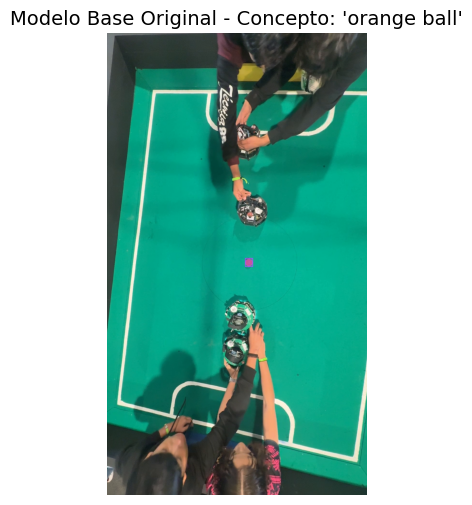


🔍 Disparando escáner para: 'robot'...
   ✅ ¡BINGO! Se detectaron 4 instancias LIMPIAS de 'robot' (Crudas: 4).


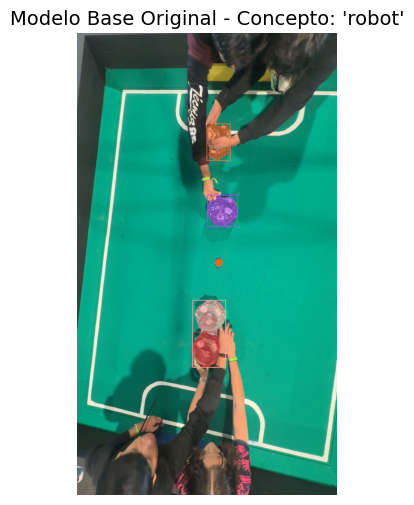


🔍 Disparando escáner para: 'player'...
   ✅ ¡BINGO! Se detectaron 3 instancias LIMPIAS de 'player' (Crudas: 3).


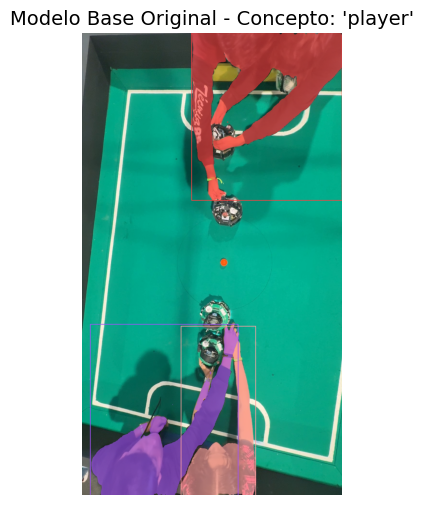

In [2]:
import cv2
import torch
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt
from PIL import Image

# Clases nativas
from transformers import Sam3Processor, Sam3Model 

VIDEO_ENTRADA = "/kaggle/input/datasets/miguelomarflores/videos-partidos-futbot/IMG_9933.MOV"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Iniciando Test Secuencial en: {device.upper()}")

print("Cargando procesador y modelo desde caché...")
processor = Sam3Processor.from_pretrained("facebook/sam3")
model = Sam3Model.from_pretrained("facebook/sam3").to(device)
model.eval()

cap = cv2.VideoCapture(VIDEO_ENTRADA)
cap.set(cv2.CAP_PROP_POS_FRAMES, 6639)
ret, frame = cap.read()
cap.release()

image_bgr = frame
image_pil = Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)) 

# Función traductora a Supervision
def sam3_a_detections(res: dict) -> sv.Detections:
    masks = res["masks"].cpu().numpy().astype(bool)
    xyxy = res["boxes"].cpu().numpy()
    scores = res["scores"].cpu().numpy()
    return sv.Detections(xyxy=xyxy, mask=masks, confidence=scores)

conceptos_busqueda = ["ball", "orange ball", "robot", "player"]

try:
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        
        # Evaluamos cada concepto uno por uno para no saturar los tensores
        for concepto in conceptos_busqueda:
            print(f"\n🔍 Disparando escáner para: '{concepto}'...")
            
            inputs = processor(
                images=image_pil,
                text=concepto,
                return_tensors="pt"
            ).to(device)

            outputs = model(**inputs)

            results = processor.post_process_instance_segmentation(
                outputs,
                threshold=0.35,  # Confianza relajada
                mask_threshold=0.5,
                target_sizes=[image_pil.size[::-1]]
            )[0]

            # 1. Obtenemos las detecciones crudas (con posibles clones)
            detecciones_crudas = sam3_a_detections(results)

            if len(detecciones_crudas) > 0:
                # =========================================================
                # 2. EL FIX NMS: Limpiamos las etiquetas dobles
                # =========================================================
                detecciones_limpias = detecciones_crudas.with_nms(threshold=0.5, class_agnostic=True)
                
                print(f"   ✅ ¡BINGO! Se detectaron {len(detecciones_limpias)} instancias LIMPIAS de '{concepto}' (Crudas: {len(detecciones_crudas)}).")
                
                # Asignamos la clase a las detecciones ya limpias
                detecciones_limpias.class_id = np.zeros(len(detecciones_limpias), dtype=int)
                
                anotador_mascaras = sv.MaskAnnotator(opacity=0.6, color_lookup=sv.ColorLookup.INDEX)
                anotador_cajas = sv.BoxAnnotator(thickness=2, color_lookup=sv.ColorLookup.INDEX)
                
                lienzo = image_bgr.copy()
                lienzo = anotador_mascaras.annotate(scene=lienzo, detections=detecciones_limpias)
                lienzo = anotador_cajas.annotate(scene=lienzo, detections=detecciones_limpias)
                
                plt.figure(figsize=(10, 6))
                plt.imshow(cv2.cvtColor(lienzo, cv2.COLOR_BGR2RGB))
                plt.title(f"Modelo Base Original - Concepto: '{concepto}'", fontsize=14)
                plt.axis("off")
                plt.show()
            else:
                print(f"   ❌ El modelo no detectó ninguna instancia de '{concepto}'.")

except Exception as e:
    print(f"\n❌ Error fatal: {e}")

### Conclusiones
En esta celda probamos diferentes etiquetas, para detectar la pelota, la etiqueta "orange ball" parece ser la más óptima ya que la etiqueta "ball" no reconoce muy bien la pelota en algunos frames. <br>
Para detectar los robots en la cancha vamos a utilizar la etiqueta "robot", en las pruebas parece detectar mejor los robots jugadores, ya que al utilizar "player" el modelo detecta a las personas y las manos que aparecen en el video. <br>
<br>
Después de esto, ya sabemos qué etiquetas utilizar para realizar la inferencia sobre el video final.

## Arquitectura de Procesamiento: Inferencia Secuencial y Limpieza

El siguiente bloque de código realiza el trabajo pesado. Se han implementado dos estrategias críticas para garantizar que el código sea reproducible y estable en tarjetas T4:

1. **Escaneo Secuencial (Anti-OOM):** En lugar de pedirle al modelo que busque a los robots y la pelota al mismo tiempo (lo cual multiplicaría los tensores y colapsaría la memoria VRAM con un error `Out of Memory`), el script evalúa un concepto a la vez por cada fotograma. 
2. **Filtro NMS (Non-Maximum Suppression):** Los objetos que se cruzan o chocan tienden a generar "cajas fantasma" (el modelo detecta a dos robots muy juntos como un solo robot gigante). Se ha configurado un umbral de (`threshold=0.5`) de tipo *Agnóstico* para triturar matemáticamente cualquier caja que se superponga, garantizando que el `.json` final tenga datos puros.

> **Nota sobre el Tiempo de Ejecución:** Para agilizar pruebas, el algoritmo está configurado con una variable `SALTO_FRAMES = 2` (procesa la mitad del video). El filtro Kalman que se usará posteriormente rellenará los huecos.

**Rutas de Archivos:**
Asegúrate de configurar todas las rutas, actualmente el código trabaja en directorios del entorno de trabajo de kaggle, es importante que las configures, especialmente si estás trabajandolo en local
* **Entrada:** Asegúrate de actualizar la variable `VIDEO_ENTRADA` con la ruta de tu video.
* **Salida:** El sistema generará el archivo base en `/kaggle/working/coordenadas_partido.json`.

In [3]:
import sys
import torch
import cv2
import json
import numpy as np
import supervision as sv
from tqdm import tqdm
from PIL import Image

from transformers import Sam3Processor, Sam3Model

VIDEO_ENTRADA = "/kaggle/input/datasets/miguelomarflores/videos-partidos-futbot/IMG_9933.MOV"
VIDEO_SALIDA = "/kaggle/working/partido1_procesado.mp4"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Iniciando Pipeline de Video en: {device.upper()}")

print("Cargando Modelo Base (facebook/sam3)...")
processor = Sam3Processor.from_pretrained("facebook/sam3")
model = Sam3Model.from_pretrained("facebook/sam3").to(device)
model.eval()

# ==========================================
# CONFIGURACIÓN DE VIDEO
# ==========================================
video_info = sv.VideoInfo.from_video_path(VIDEO_ENTRADA)
generador_video = sv.get_video_frames_generator(VIDEO_ENTRADA)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_video = cv2.VideoWriter(VIDEO_SALIDA, fourcc, video_info.fps, (video_info.width, video_info.height))

# ==========================================
# ANOTADORES VISUALES
# ==========================================
# Usaremos una paleta de colores fija para distinguir clases
# 0 = player, 1 = orange ball
anotador_mascaras = sv.MaskAnnotator(opacity=0.6, color_lookup=sv.ColorLookup.CLASS)
anotador_etiquetas = sv.LabelAnnotator(text_scale=0.5, color_lookup=sv.ColorLookup.CLASS)

conceptos = ["robot", "orange ball"]

# ==========================================
# CONFIGURACIÓN DE OPTIMIZACIÓN
# ==========================================
SALTO_FRAMES = 2  # Procesa 1 cuadro, salta el siguiente (Corta el tiempo a la mitad)
registro_datos = {} # Aquí guardaremos los números crudos para ByteTrack

print(f"Iniciando procesamiento (Procesando 1 de cada {SALTO_FRAMES} cuadros)...")

try:
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        
        for frame_idx, frame in enumerate(tqdm(generador_video, total=video_info.total_frames)):
            
            # EL HACK DE VELOCIDAD
            if frame_idx % SALTO_FRAMES != 0:
                continue 
            
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image_pil = Image.fromarray(image_rgb)
            
            todas_cajas = []
            todas_mascaras = []
            todas_confianzas = []
            todas_clases = []
            etiquetas_visuales = []
            
            for id_clase, concepto in enumerate(conceptos):
                inputs = processor(images=image_pil, text=concepto, return_tensors="pt").to(device)
                outputs = model(**inputs)
                
                results = processor.post_process_instance_segmentation(
                    outputs,
                    threshold=0.35,  
                    mask_threshold=0.5,
                    target_sizes=[image_pil.size[::-1]]
                )[0]
                
                mascaras_crude = results["masks"].cpu().numpy().astype(bool)
                cajas_crude = results["boxes"].cpu().numpy()
                scores_crude = results["scores"].cpu().numpy()
                
                if len(mascaras_crude) > 0:
                    todas_cajas.extend(cajas_crude)
                    todas_mascaras.extend(mascaras_crude) 
                    todas_confianzas.extend(scores_crude.tolist())
                    todas_clases.extend([id_clase] * len(scores_crude))
                    #etiquetas_visuales.extend([f"{concepto} {score:.2f}" for score in scores_crude])
            
            lienzo = frame.copy()
            if len(todas_cajas) > 0:
                # 1. RENDERIZADO VISUAL
                detecciones_unificadas = sv.Detections(
                    xyxy=np.array(todas_cajas),
                    mask=np.array(todas_mascaras), 
                    confidence=np.array(todas_confianzas),
                    class_id=np.array(todas_clases)
                )
                
                # EL FILTRO NMS (Destruye clones)
                detecciones_limpias = detecciones_unificadas.with_nms(threshold=0.25, class_agnostic=True)
                
                # EL FIX: Generar las etiquetas DESPUÉS de la limpieza
                # Usamos la lista de conceptos original ("player", "orange ball")
                etiquetas_limpias = [
                    f"{conceptos[clase_id]} {conf:.2f}" 
                    for clase_id, conf in zip(detecciones_limpias.class_id, detecciones_limpias.confidence)
                ]
                
                lienzo = anotador_mascaras.annotate(scene=lienzo, detections=detecciones_limpias)
                lienzo = anotador_etiquetas.annotate(scene=lienzo, detections=detecciones_limpias, labels=etiquetas_limpias)
                
                # 2. GUARDADO DE DATOS CRUDOS
                registro_datos[frame_idx] = {
                    "cajas": [caja.tolist() for caja in detecciones_limpias.xyxy], 
                    "confianzas": detecciones_limpias.confidence.tolist(),
                    "clases": detecciones_limpias.class_id.tolist()
                }
            
            out_video.write(lienzo)

    # AL TERMINAR EL BUCLE, EXPORTAMOS EL CEREBRO A UN ARCHIVO
    print("\nGuardando datos crudos para el rastreador...")
    with open('/kaggle/working/coordenadas_partido.json', 'w') as f:
        json.dump(registro_datos, f)

except Exception as e:
    print(f"\n❌ Error durante el pipeline: {e}")
finally:
    out_video.release()
    print(f"\n✅ Video guardado en: {VIDEO_SALIDA}")
    print("✅ JSON guardado en: /kaggle/working/coordenadas_partido.json")

Iniciando Pipeline de Video en: CUDA
Cargando Modelo Base (facebook/sam3)...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Iniciando procesamiento (Procesando 1 de cada 2 cuadros)...


100%|█████████▉| 23274/23278 [4:18:26<00:02,  1.50it/s]



Guardando datos crudos para el rastreador...

✅ Video guardado en: /kaggle/working/partido1_procesado.mp4
✅ JSON guardado en: /kaggle/working/coordenadas_partido.json
